# Jev-as-a-Judge: avaliando resumos de artigos da Wikipedia

Este notebook demonstra um pipeline completo:

1. Buscar um tópico na **Wikipedia**.
2. Usar uma **LLM da OpenAI** para produzir um resumo com base somente no artigo recuperado.
3. Usar **Jev** como *judge* estruturado para avaliar o resumo em cinco dimensões:
   - `correctness`
   - `groundedness`
   - `relevance`
   - `hallucination`
   - `omission`
4. Organizar os resultados em um `DataFrame`.
5. Visualizar os scores.
6. Aplicar uma política programática de aprovação/revisão.

## Interpretação dos scores

Todos os critérios usam `Noul`, portanto retornam uma probabilidade entre `0` e `1`.

| Critério | Pergunta conceitual | Melhor direção |
|---|---|---|
| `correctness` | O resumo está factualmente correto em relação à fonte? | ↑ maior é melhor |
| `groundedness` | As afirmações do resumo são sustentadas pela fonte? | ↑ maior é melhor |
| `relevance` | O resumo responde ao objetivo e se mantém no tópico? | ↑ maior é melhor |
| `hallucination` | O resumo introduz afirmações não sustentadas pela fonte? | ↓ menor é melhor |
| `omission` | O resumo omite informações importantes da fonte? | ↓ menor é melhor |

> O Jev funciona aqui como juiz probabilístico e estruturado. A política final de aprovação é definida em Python.

## Dependências

No projeto gerenciado com `uv`:

```bash
uv add openai requests python-dotenv pandas seaborn matplotlib typesafe-sdk
uv add --dev jupyterlab ipykernel
```

No arquivo `.env`:

```text
OPENAI_API_KEY=sua-chave-openai
TYPESAFE_API_KEY=sua-chave-typesafe
```

In [1]:
from __future__ import annotations

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import requests

from dotenv import load_dotenv
from openai import OpenAI
from typesafe_sdk import TypeSafeClient, Noul

load_dotenv()

assert os.getenv("OPENAI_API_KEY"), "Defina OPENAI_API_KEY no arquivo .env"
assert os.getenv("TYPESAFE_API_KEY"), "Defina TYPESAFE_API_KEY no arquivo .env"

## 1. Configuração do experimento

O notebook é parametrizado para trocar facilmente o idioma da Wikipedia, o tópico, o modelo da OpenAI e o tamanho máximo do contexto. O exemplo inicial usa **Albert Einstein** na Wikipedia em português.

In [2]:
WIKIPEDIA_LANGUAGE = "pt"
WIKIPEDIA_TITLE = "Albert Einstein"

# Troque por outro modelo disponível em sua conta, se desejar.
OPENAI_MODEL = "gpt-5-mini"

MAX_SOURCE_CHARS = 18_000
SUMMARY_MAX_WORDS = 450

## 2. Buscar o artigo na Wikipedia

Usaremos a API do MediaWiki diretamente e recuperaremos o texto em formato puro.

In [3]:
def fetch_wikipedia_article(title: str, language: str = "pt") -> dict:
    api_url = f"https://{language}.wikipedia.org/w/api.php"
    params = {
        "action": "query",
        "prop": "extracts|info",
        "explaintext": 1,
        "inprop": "url",
        "redirects": 1,
        "titles": title,
        "format": "json",
        "formatversion": 2,
    }
    headers = {
        "User-Agent": "JevJudgeStudy/1.0 (educational Jupyter notebook)"
    }
    response = requests.get(api_url, params=params, headers=headers, timeout=30)
    response.raise_for_status()
    pages = response.json()["query"]["pages"]
    if not pages or pages[0].get("missing"):
        raise ValueError(f"Artigo não encontrado: {title}")
    page = pages[0]
    return {
        "title": page["title"],
        "url": page.get("fullurl"),
        "text": page.get("extract", ""),
    }

article = fetch_wikipedia_article(WIKIPEDIA_TITLE, WIKIPEDIA_LANGUAGE)
print("Título:", article["title"])
print("URL:", article["url"])
print("Caracteres:", len(article["text"]))

Título: Albert Einstein
URL: https://pt.wikipedia.org/wiki/Albert_Einstein
Caracteres: 75649


In [4]:
print(article["text"][:4_000])

Albert Einstein (Ulm, 14 de março de 1879 – Princeton, 18 de abril de 1955) foi um físico teórico alemão que desenvolveu a teoria da relatividade geral, um dos pilares da física moderna ao lado da mecânica quântica. Embora mais conhecido por sua fórmula de equivalência massa–energia, E = mc² — que foi chamada de "a equação mais famosa do mundo" —, foi laureado com o Prêmio Nobel de Física de 1921 "por suas contribuições à física teórica" e, especialmente, por sua descoberta da lei do efeito fotoelétrico, que foi fundamental no estabelecimento da teoria quântica.
Nascido em uma família de judeus alemães, mudou-se para a Suíça ainda jovem e iniciou seus estudos na Escola Politécnica de Zurique. Após dois anos procurando emprego, obteve um cargo no escritório de patentes suíço enquanto ingressava no curso de doutorado da Universidade de Zurique. Em 1905, publicou uma série de artigos acadêmicos revolucionários. Uma de suas obras era o desenvolvimento da teoria da relatividade especial. Pe

## 3. Preparar o contexto-fonte

O mesmo trecho-fonte será usado tanto para gerar o resumo quanto para avaliá-lo. Isso torna `groundedness`, `hallucination` e `omission` explicitamente relativos à mesma referência.

In [5]:
source_text = article["text"][:MAX_SOURCE_CHARS]
print("Caracteres enviados ao pipeline:", len(source_text))
print()
print(source_text[:2_000])

Caracteres enviados ao pipeline: 18000

Albert Einstein (Ulm, 14 de março de 1879 – Princeton, 18 de abril de 1955) foi um físico teórico alemão que desenvolveu a teoria da relatividade geral, um dos pilares da física moderna ao lado da mecânica quântica. Embora mais conhecido por sua fórmula de equivalência massa–energia, E = mc² — que foi chamada de "a equação mais famosa do mundo" —, foi laureado com o Prêmio Nobel de Física de 1921 "por suas contribuições à física teórica" e, especialmente, por sua descoberta da lei do efeito fotoelétrico, que foi fundamental no estabelecimento da teoria quântica.
Nascido em uma família de judeus alemães, mudou-se para a Suíça ainda jovem e iniciou seus estudos na Escola Politécnica de Zurique. Após dois anos procurando emprego, obteve um cargo no escritório de patentes suíço enquanto ingressava no curso de doutorado da Universidade de Zurique. Em 1905, publicou uma série de artigos acadêmicos revolucionários. Uma de suas obras era o desenvolviment

## 4. Gerar o resumo com a OpenAI

O modelo recebe somente o texto recuperado da Wikipedia como fonte factual. O exemplo usa a **Responses API**.

In [6]:
openai_client = OpenAI()

summary_prompt = f"""
Você receberá um texto-fonte extraído da Wikipedia.

Tarefa:
Produza um resumo em português sobre a história e a trajetória de {article['title']}.

Regras:
- Use somente informações presentes no texto-fonte.
- Não acrescente fatos externos, mesmo que você os conheça.
- Preserve datas, nomes, locais e acontecimentos importantes.
- Priorize os principais acontecimentos biográficos e científicos.
- Evite detalhes periféricos.
- Produza no máximo {SUMMARY_MAX_WORDS} palavras.

TEXTO-FONTE:
{source_text}
"""

openai_response = openai_client.responses.create(
    model=OPENAI_MODEL,
    input=summary_prompt,
)

summary = openai_response.output_text
print(summary)

Albert Einstein (Ulm, 14 de março de 1879 – Princeton, 18 de abril de 1955) foi um físico teórico alemão cuja obra transformou a física moderna. Nascido em família de judeus asquenazes não praticantes, mudou‑se ainda jovem para Munique e, após problemas empresariais da família, para a Itália. Em 1895 entrou na Escola Politécnica Federal Suíça (ETH Zurique) após completar os estudos em Aarau; renunciou à cidadania do Reino de Württemberg em 1896 e naturalizou‑se suíço em 1901.

Seu primeiro artigo, "Conclusões Retiradas dos Fenômenos da Capilaridade", foi publicado em Annalen der Physik em 1901. Em 1902 começou a trabalhar no Escritório de Patentes de Berna (Instituto Federal Suíço de Propriedade Intelectual), conciliando o emprego com o doutorado na Universidade de Zurique, concluído em 30 de abril de 1905. Em 1905 — o chamado "Ano Miraculoso" — publicou quatro artigos fundamentais sobre o efeito fotoelétrico, o movimento browniano, a teoria da relatividade especial e a equivalência ma

## 5. Construir o estado do Jev-as-a-Judge

O estado contém a fonte, a tarefa e a resposta produzida.

In [7]:
judge_state = {
    "source": source_text,
    "task": (
        f"Produzir um resumo em português sobre a história e a trajetória "
        f"de {article['title']}, usando somente informações presentes "
        f"no texto-fonte e priorizando acontecimentos importantes."
    ),
    "answer": summary,
}

## 6. Rubrica do Jev

- **Correctness:** as afirmações factuais estão corretas segundo a fonte?
- **Groundedness:** as afirmações são sustentadas pela fonte?
- **Relevance:** o resumo atende à tarefa e permanece focado?
- **Hallucination:** há afirmações factuais não sustentadas? **Menor é melhor.**
- **Omission:** faltam fatos importantes a ponto de enfraquecer o resumo? **Menor é melhor.**

Separar `correctness` de `groundedness` é útil: algo pode ser verdadeiro no mundo real, mas não estar sustentado pela fonte fornecida.

In [8]:
judge_questions = {
    "correctness": Noul(
        instructions=(
            "Considering `source`, `task`, and `answer`, are the factual "
            "claims in `answer` correct according to `source`?"
        ),
        criteria={
            "true": "The factual claims are consistent with the source, with no material factual errors or contradictions.",
            "false": "The answer contains one or more material factual errors, misstatements, or contradictions relative to the source.",
        },
    ),
    "groundedness": Noul(
        instructions=(
            "Considering `source` and `answer`, are the factual claims in "
            "`answer` supported by information contained in `source`?"
        ),
        criteria={
            "true": "The answer is grounded in the source and its factual claims can be supported by it.",
            "false": "The answer materially relies on claims that are not supported by the source.",
        },
    ),
    "relevance": Noul(
        instructions=(
            "Considering `task` and `answer`, does `answer` directly satisfy "
            "the requested summarization task and stay focused on the important "
            "history and trajectory described in the source?"
        ),
        criteria={
            "true": "The answer directly addresses the requested topic and prioritizes information relevant to the task.",
            "false": "The answer is substantially off-topic, poorly focused, or fails to address the requested task.",
        },
    ),
    "hallucination": Noul(
        instructions=(
            "Considering `source` and `answer`, does `answer` contain any material factual "
            "claim, detail, relationship, date, event, interpretation presented as fact, "
            "or attribution that is not supported by `source`?"
        ),
        criteria={
            "true": "The answer contains at least one material unsupported factual claim or invented detail.",
            "false": "The answer does not materially introduce factual claims beyond what the source supports.",
        },
    ),
    "omission": Noul(
        instructions=(
            "Considering `source`, `task`, and `answer`, does `answer` omit one or more "
            "major facts or events important enough that their absence materially weakens "
            "the requested summary?"
        ),
        criteria={
            "true": "Important information central to the requested summary is missing to a material degree.",
            "false": "The summary covers the major information needed for the requested level of summarization, even if minor details are omitted.",
        },
    ),
}

## 7. Executar o Jev-as-a-Judge

In [9]:
with TypeSafeClient() as jev_client:
    judge_response = jev_client.system_one(
        state=judge_state,
        questions=judge_questions,
    )

judge_scores = {
    name: judge_response.answers[name].noul
    for name in judge_questions
}

judge_scores

{'correctness': 0.85,
 'groundedness': 0.91,
 'relevance': 0.96,
 'hallucination': 0.17,
 'omission': 0.35}

## 8. Organizar os resultados

Para visualização, convertemos os critérios negativos para a direção **maior = melhor**:

- `no_hallucination = 1 - hallucination`
- `completeness = 1 - omission`

Os scores originais permanecem preservados.

In [10]:
results = pd.DataFrame([
    {"criterion": "correctness", "score": judge_scores["correctness"], "interpretation": "higher_is_better"},
    {"criterion": "groundedness", "score": judge_scores["groundedness"], "interpretation": "higher_is_better"},
    {"criterion": "relevance", "score": judge_scores["relevance"], "interpretation": "higher_is_better"},
    {"criterion": "hallucination", "score": judge_scores["hallucination"], "interpretation": "lower_is_better"},
    {"criterion": "omission", "score": judge_scores["omission"], "interpretation": "lower_is_better"},
])
results

,criterion,score,interpretation
0,correctness,0.85,higher_is_better
1,groundedness,0.91,higher_is_better
2,relevance,0.96,higher_is_better
3,hallucination,0.17,lower_is_better
4,omission,0.35,lower_is_better


In [11]:
quality_scores = pd.DataFrame([
    {"criterion": "Correctness", "quality_score": judge_scores["correctness"]},
    {"criterion": "Groundedness", "quality_score": judge_scores["groundedness"]},
    {"criterion": "Relevance", "quality_score": judge_scores["relevance"]},
    {"criterion": "No hallucination", "quality_score": 1 - judge_scores["hallucination"]},
    {"criterion": "Completeness", "quality_score": 1 - judge_scores["omission"]},
])
quality_scores

,criterion,quality_score
0,Correctness,0.85
1,Groundedness,0.91
2,Relevance,0.96
3,No hallucination,0.83
4,Completeness,0.65


## 9. Visualizar a avaliação

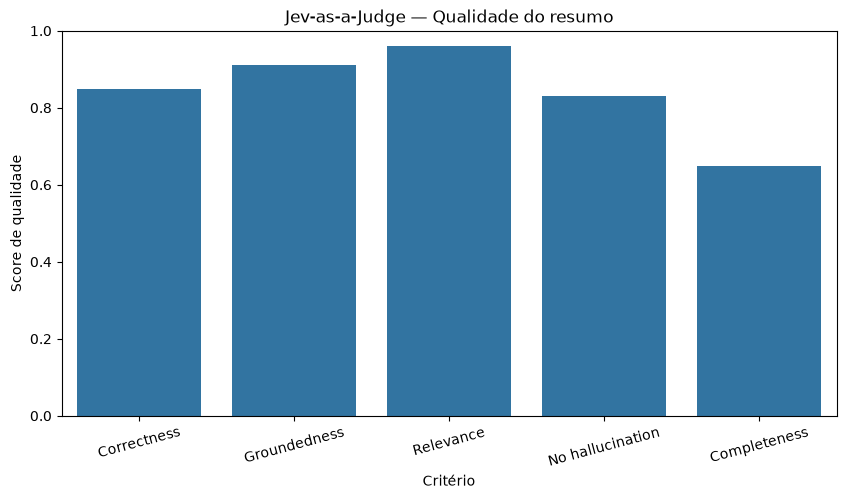

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(data=quality_scores, x="criterion", y="quality_score")
plt.ylim(0, 1)
plt.xlabel("Critério")
plt.ylabel("Score de qualidade")
plt.title("Jev-as-a-Judge — Qualidade do resumo")
plt.xticks(rotation=15)
plt.show()

## 10. Score agregado opcional

A média abaixo é apenas uma política definida pela aplicação, não uma métrica oficial do Jev.

In [13]:
overall_quality = quality_scores["quality_score"].mean()
print(f"Qualidade agregada: {overall_quality:.3f}")

Qualidade agregada: 0.840


## 11. Política programática de aprovação

Exemplo:

- correctness ≥ 0.80
- groundedness ≥ 0.80
- relevance ≥ 0.80
- hallucination ≤ 0.20
- omission ≤ 0.30

In [14]:
POLICY = {
    "min_correctness": 0.80,
    "min_groundedness": 0.80,
    "min_relevance": 0.80,
    "max_hallucination": 0.20,
    "max_omission": 0.30,
}

passed = (
    judge_scores["correctness"] >= POLICY["min_correctness"]
    and judge_scores["groundedness"] >= POLICY["min_groundedness"]
    and judge_scores["relevance"] >= POLICY["min_relevance"]
    and judge_scores["hallucination"] <= POLICY["max_hallucination"]
    and judge_scores["omission"] <= POLICY["max_omission"]
)

print("PASS" if passed else "REVIEW")

REVIEW


## 12. Diagnóstico determinístico

O texto abaixo é produzido por regras em Python, e não por uma racionalização livre do modelo.

In [15]:
def build_diagnostic(scores: dict[str, float]) -> list[str]:
    messages = []
    if scores["correctness"] < 0.80:
        messages.append("Correctness abaixo do threshold: revisar possíveis erros factuais.")
    if scores["groundedness"] < 0.80:
        messages.append("Groundedness abaixo do threshold: há risco de afirmações pouco sustentadas.")
    if scores["relevance"] < 0.80:
        messages.append("Relevance abaixo do threshold: o resumo pode estar pouco focado no objetivo.")
    if scores["hallucination"] > 0.20:
        messages.append("Hallucination acima do threshold: investigar afirmações não suportadas.")
    if scores["omission"] > 0.30:
        messages.append("Omission acima do threshold: verificar fatos importantes ausentes.")
    if not messages:
        messages.append("Nenhum critério ultrapassou os limites definidos para revisão.")
    return messages

for item in build_diagnostic(judge_scores):
    print("-", item)

- Omission acima do threshold: verificar fatos importantes ausentes.


## 13. Inspeção conjunta

In [16]:
print("=" * 80)
print("FONTE")
print("=" * 80)
print(article["title"])
print(article["url"])

print()
print("=" * 80)
print("RESUMO OPENAI")
print("=" * 80)
print(summary)

print()
print("=" * 80)
print("JEV-AS-A-JUDGE")
print("=" * 80)
for criterion, score in judge_scores.items():
    print(f"{criterion:15s}: {score:.3f}")
print()
print("Decisão da política:", "PASS" if passed else "REVIEW")

FONTE
Albert Einstein
https://pt.wikipedia.org/wiki/Albert_Einstein

RESUMO OPENAI
Albert Einstein (Ulm, 14 de março de 1879 – Princeton, 18 de abril de 1955) foi um físico teórico alemão cuja obra transformou a física moderna. Nascido em família de judeus asquenazes não praticantes, mudou‑se ainda jovem para Munique e, após problemas empresariais da família, para a Itália. Em 1895 entrou na Escola Politécnica Federal Suíça (ETH Zurique) após completar os estudos em Aarau; renunciou à cidadania do Reino de Württemberg em 1896 e naturalizou‑se suíço em 1901.

Seu primeiro artigo, "Conclusões Retiradas dos Fenômenos da Capilaridade", foi publicado em Annalen der Physik em 1901. Em 1902 começou a trabalhar no Escritório de Patentes de Berna (Instituto Federal Suíço de Propriedade Intelectual), conciliando o emprego com o doutorado na Universidade de Zurique, concluído em 30 de abril de 1905. Em 1905 — o chamado "Ano Miraculoso" — publicou quatro artigos fundamentais sobre o efeito fotoelé

# 14. Experimento controlado: introduzir uma alucinação

A próxima célula adiciona deliberadamente uma afirmação falsa/não sustentada para testar o judge.

> A frase é artificial e serve somente para o experimento.

In [17]:
summary_with_injected_claim = (
    summary
    + "\n\n"
    + "Além disso, Einstein teria exercido o cargo de presidente da Suíça por dois mandatos."
)

test_state = {
    "source": source_text,
    "task": judge_state["task"],
    "answer": summary_with_injected_claim,
}

with TypeSafeClient() as jev_client:
    injected_response = jev_client.system_one(
        state=test_state,
        questions=judge_questions,
    )

injected_scores = {
    name: injected_response.answers[name].noul
    for name in judge_questions
}

pd.DataFrame({
    "criterion": list(judge_scores.keys()),
    "original": [judge_scores[k] for k in judge_scores],
    "with_injected_claim": [injected_scores[k] for k in judge_scores],
})

,criterion,original,with_injected_claim
0,correctness,0.85,0.04
1,groundedness,0.91,0.05
2,relevance,0.96,0.43
3,hallucination,0.17,0.98
4,omission,0.35,0.42


## 15. Comparar visualmente o resumo original com o adulterado

O comportamento esperado é `hallucination` aumentar e `groundedness/correctness` diminuírem. As magnitudes devem ser observadas empiricamente.

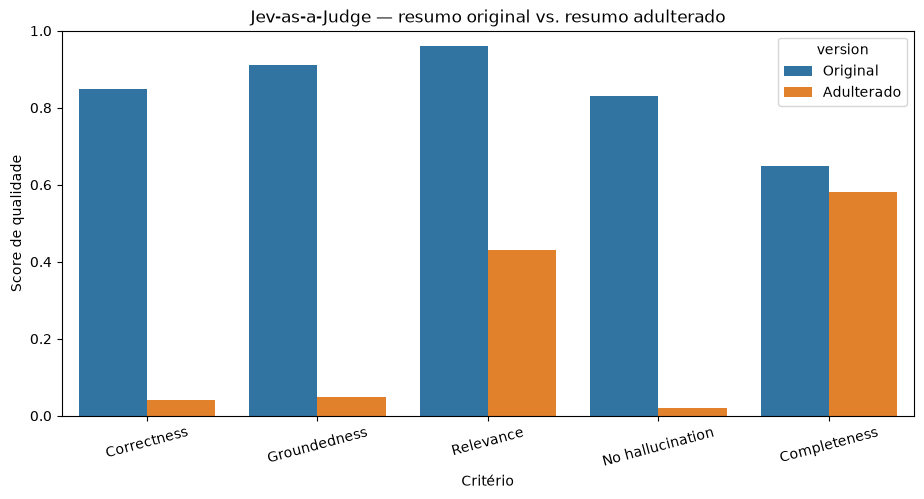

In [18]:
comparison = pd.DataFrame({
    "criterion": ["Correctness", "Groundedness", "Relevance", "No hallucination", "Completeness"],
    "Original": [
        judge_scores["correctness"],
        judge_scores["groundedness"],
        judge_scores["relevance"],
        1 - judge_scores["hallucination"],
        1 - judge_scores["omission"],
    ],
    "Adulterado": [
        injected_scores["correctness"],
        injected_scores["groundedness"],
        injected_scores["relevance"],
        1 - injected_scores["hallucination"],
        1 - injected_scores["omission"],
    ],
})

comparison_long = comparison.melt(
    id_vars="criterion",
    var_name="version",
    value_name="quality_score",
)

plt.figure(figsize=(11, 5))
sns.barplot(data=comparison_long, x="criterion", y="quality_score", hue="version")
plt.ylim(0, 1)
plt.xlabel("Critério")
plt.ylabel("Score de qualidade")
plt.title("Jev-as-a-Judge — resumo original vs. resumo adulterado")
plt.xticks(rotation=15)
plt.show()